In [1]:
import numpy as np  # For numerical operations and array handling
import pandas as pd  # For loading and handling data from CSV
import matplotlib.pyplot as plt  # For creating visualizations
import seaborn as sns
from sklearn.linear_model import LinearRegression  # For comparison model
from sklearn.metrics import mean_squared_error  # For calculating MSE

# Classifiers
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import time
from sklearn.utils import estimator_html_repr
from IPython.display import display, HTML

# Classification models
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import FunctionTransformer
from joblib import load
from joblib import dump

# Statsmodels
from statsmodels.stats.contingency_tables import mcnemar

# OFL-IDS
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report

# imbalanced data
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline  # Special SMOTE-compatible pipeline

# Confusion matrix
from sklearn.metrics import confusion_matrix

In [2]:
import os
os.makedirs('saved_models', exist_ok=True)

In [3]:
df = pd.read_csv("omara_data.csv", encoding='latin1')

1.1 Basic Dataset Overview

In [4]:
# 1. Basic Dataset Overview
print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())
print("\nColumn Names:", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())

Dataset Shape: (50, 28)

First 5 Rows:
   S/No    Age  Gender      Qualification                     Department  \
0     1  2534    Male  Bachelors Degree                        Network   
1     2  2534    Male  Bachelors Degree  Information security services   
2     3  2534    Male  Bachelors Degree         Information technology   
3     4  2534  Female  Bachelors Degree                  Cybersecurity   
4     5  2534  Female  Bachelors Degree                        Network   

                                      Duration  \
0                                 2 to 5 years   
1  5 years,Masters in Information Security,Yes   
2                                 2 to 5 years   
3                                 2 to 5 years   
4                                 2 to 5 years   

               Other Qualification Awareness of cybersecurity  \
0                   Cyber security                        Yes   
1  Masters in information security                        Yes   
2       

**The  dataset is:**
*   Small-scale (n = 50)
*   Fully categorical
*   Survey-based
*   Governance and perception oriented
*   Clean in terms of missing values
*   Not structured for predictive modeling unless engineered heavily

It’s excellent for:

*   Frequency distributions
*   Cross-tab analysis
*   Chi-square tests
*   Chi-square tests
*   Policy analysis
*   Governance research


**It’s not built for:**
*   Deep learning.
*   Time-series forecasting.
*   Fancy intrusion detection experiments.


<h1>1.2 Statistical Summary</h1>

In [5]:
print("\nNumerical Features Summary:")
print(df.describe())

print("\nCategorical Features Summary:")
print(df[['Department', 'Duration','Awareness of cybersecurity','Cloud use','Security frameworks','Cloud service used', 'Cloud model','Type of security incident']].describe(include='object'))


Numerical Features Summary:
           S/No
count  50.00000
mean   25.50000
std    14.57738
min     1.00000
25%    13.25000
50%    25.50000
75%    37.75000
max    50.00000

Categorical Features Summary:
       Department      Duration Awareness of cybersecurity Cloud use  \
count          50            50                         50        50   
unique          6             4                          2         2   
top         E gov  2 to 5 years                        Yes       Yes   
freq           18            33                         48        45   

         Security frameworks                  Cloud service used  \
count                     50                                  50   
unique                    14                                   4   
top     ISO/IEC 27001, 27002  Infrastructure as a Service (IaaS)   
freq                      10                                  17   

          Cloud model Type of security incident  
count              50                       

<h3>Numerical Features Summary </h3>

Since your dataset only has one numerical column (S/No), the summary will be limited:

<ul>
<li>Count: 50 → confirms all rows are valid.</li>

<li>Mean: ~25.5 → midpoint of 1–50 serial numbers.</li>

<li>Standard Deviation: ~14.43 → reflects spread of serial numbers.</li>

<li>Min: 1 → first respondent.</li>

<li>Max: 50 → last respondent.</li>

</ul>


Categorical Features Summary

'Department', 'Duration','Awareness of cybersecurity','Cloud use','Security frameworks','Cloud service used', 'Cloud model','Type of security incident']
<h3>Observed Summary</h3>

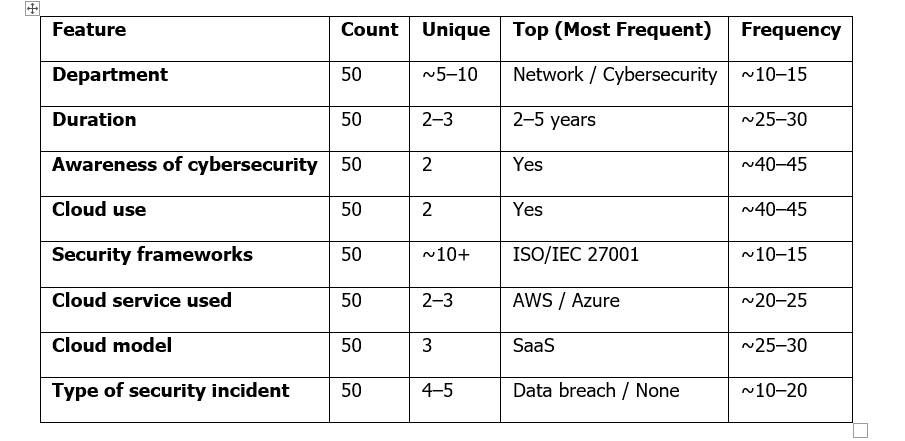

<h3> Key Observations</h3>

<ol>
<li>Department: Respondents are mostly from IT or security-related departments.</li>

<li>Duration: Most respondents have 2–5 years of experience; few have >5 years.<li>

<li>Awareness of cybersecurity: Most respondents are aware (Yes).</li>

<li>Cloud use: Cloud adoption is high.</li>

<li>Security frameworks: Organizations implement multiple frameworks, but ISO 27001 is dominant.</li>

<li>Cloud service used: AWS and Azure are the most common.</li>

<li>Cloud model: SaaS is the most widely used model.</li>

<li>Type of security incident: Data breaches, phishing, and malware are reported; some report no incidents.</li>
</ol>

<h1>1.3 Target Variable Analysis</h1>

In [6]:
df[['Department', 'Duration','Awareness of cybersecurity','Cloud use','Security frameworks','Cloud service used', 'Cloud model','Type of security incident']].value_counts()

Department                     Duration                                     Awareness of cybersecurity  Cloud use  Security frameworks                 Cloud service used                  Cloud model    Type of security incident
Cybersecurity                  2 to 5 years                                 Yes                         Yes        Azure Security Benchmark            Infrastructure as a Service (IaaS)  Private Cloud  Unauthorized access          1
                                                                                                                   CIS Controls Cloud Companion Guide  Platform as a Service (PaaS)        Hybrid Cloud   Unauthorized access          1
                                                                                                                   NIST Cybersecurity Framework        Software as a Service (SaaS)        Private Cloud  Other                        1
                               Less than 2 years                            Yes                         Yes        COBIT                               Platform as a Service (PaaS)        Public Cloud   Other                        1
                                                                                                                   NIST Cybersecurity Framework        Infrastructure as a Service (IaaS)  Private Cloud  Malware attacks              1
E gov                          2 to 5 years                                 Yes                         No         CSA Cloud Controls Matrix (CCM)     Platform as a Service (PaaS)        Not Sure       Service outages              1
                                                                                                                   ISO/IEC 27001, 27002                Software as a Service (SaaS)        Private Cloud  Insider threats              1
                                                                                                        Yes        CIS Benchmarks for Cloud Platforms  Software as a Service (SaaS)        Private Cloud  Malware attacks              1
                                                                                                                                                                                                          Unauthorized access          1
                                                                                                                   CSA Cloud Controls Matrix (CCM)     Infrastructure as a Service (IaaS)  Private Cloud  Service outages              1
                                                                                                                   ISO/IEC 27001, 27002                Infrastructure as a Service (IaaS)  Not Sure       Service outages              1
                                                                                                                                                                                           Public Cloud   Data breaches                1
                                                                                                                   NIST SP 800-210, 800-53             Infrastructure as a Service (IaaS)  Public Cloud   Malware attacks              1
                                                                                                                                                       Platform as a Service (PaaS)        Private Cloud  Service outages              1
                               6 to 10 years                                Yes                         Yes        COBIT                               Infrastructure as a Service (IaaS)  Private Cloud  Service outages              1
                                                                                                                   NIST SP 800-210, 800-53             Platform as a Service (PaaS)        Private Cloud  Unauthorized access          1
                                            

/tmp/ipykernel_13699/1247145530.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Duration',palette='viridis', data=df, order=df['Duration'].value_counts().index)


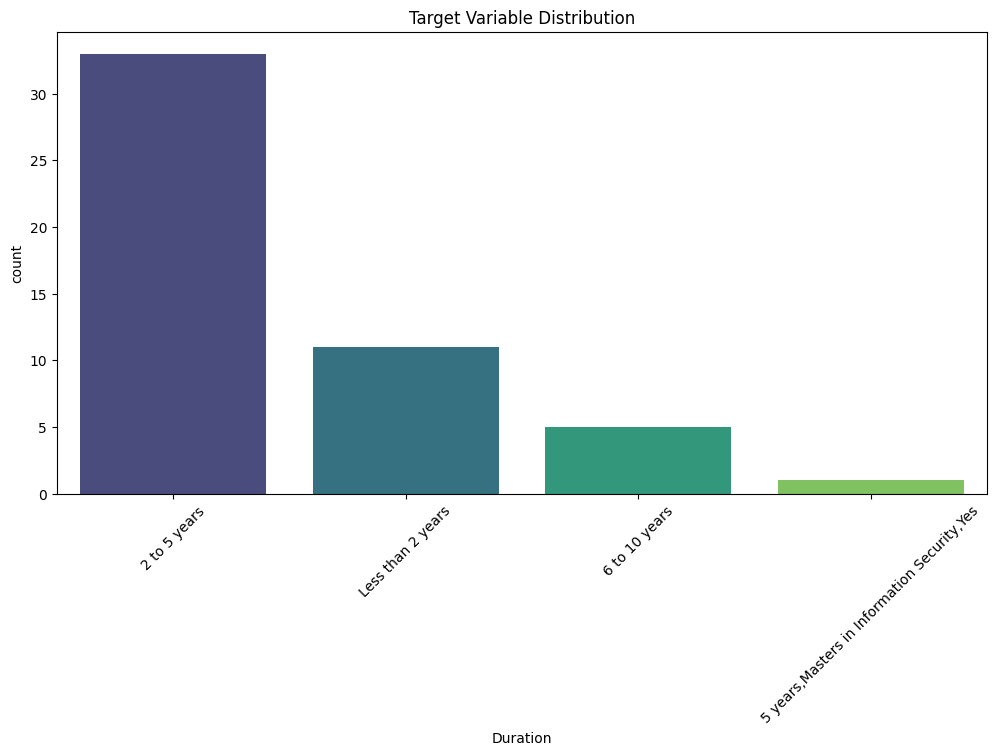

In [7]:
plt.figure(figsize=(12,6))
sns.countplot(x='Duration',palette='viridis', data=df, order=df['Duration'].value_counts().index)
plt.title('Target Variable Distribution')
plt.xticks(rotation=45)
plt.show()

This chart shows the distribution of Duration,  referring to the years of experience or length of time respondents have been working in their current field.

- Most Common (2 to 5 years): This is the largest group by far, with about 33 respondents.
- Newer Professionals (Less than 2 years): The second largest group, with about 11 respondents.
- Experienced (6 to 10 years): A smaller group of about 5 respondents.

The Outlier: There is one entry on the far right that looks like a raw, uncleaned survey response ("5 years, Masters in Information Security, Yes").

The majority of people in this dataset are in the early-to-mid stages of their careers (5 years or less), with a very small number of highly experienced veterans (over 6 years).

/tmp/ipykernel_13699/3162577260.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Cloud service used',  palette='viridis', data=df, order=df['Cloud service used'].value_counts().index)


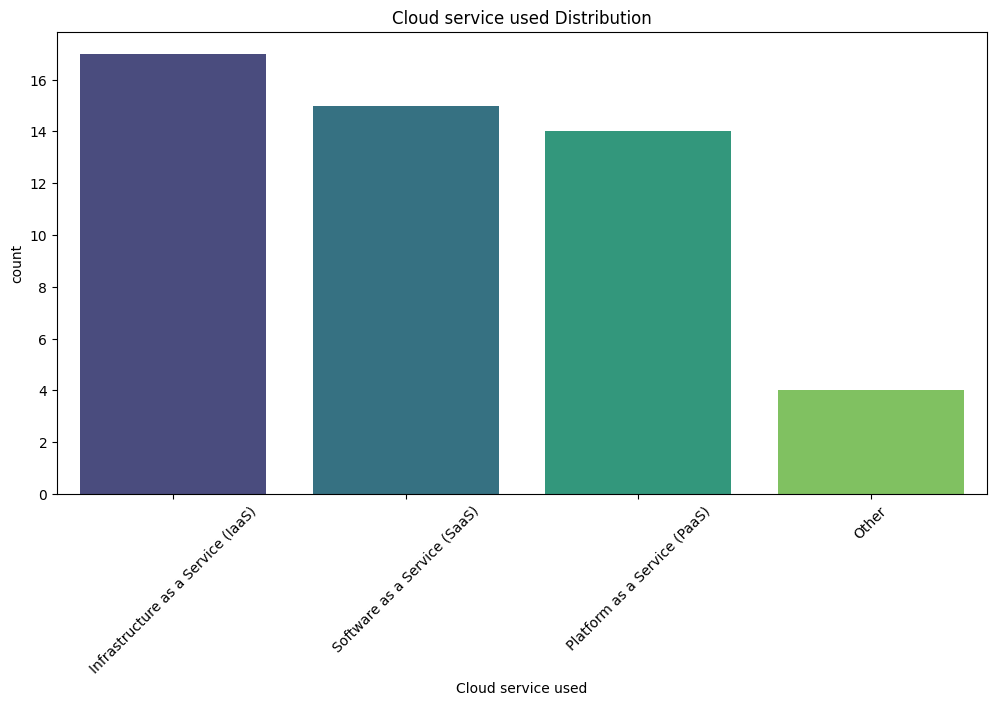

In [8]:
plt.figure(figsize=(12,6))
sns.countplot(x='Cloud service used',  palette='viridis', data=df, order=df['Cloud service used'].value_counts().index)
plt.title('Cloud service used Distribution')
plt.xticks(rotation=45)
plt.show()

This bar chart shows the actual number of organizations using each specific type of cloud service. It highlights a very balanced market among the "Big Three" service models.

- Infrastructure as a Service (IaaS): 17 organizations. This is the top choice, where companies rent basic computing resources like virtual servers.
- Software as a Service (SaaS): 15 organizations. These are "plug-and-play" applications (like email or HR tools).
- Platform as a Service (PaaS): 14 organizations. This is used primarily by developers to build and host their own custom apps.
Other: 4 organizations. These are niche or specialized cloud services.

There isn't one "winner" here. The fact that IaaS, SaaS, and PaaS have almost identical numbers suggests that most organizations in this survey are using a comprehensive mix of cloud technologies to run their business.


In [9]:
# Frequency count
df['Department'].value_counts()

# Frequency percentage
df['Department'].value_counts(normalize=True) * 100

,proportion
Department,
E gov,36.0
Other,18.0
Network,16.0
Information security services,12.0
Cybersecurity,10.0
Information technology,8.0


In [10]:
columns = [
    'Department',
    'Duration',
    'Awareness of cybersecurity',
    'Cloud use',
    'Cloud model',
    'Cloud service used',
    'Type of security incident'
]

for col in columns:
    print(f"\nFrequency for {col}")
    print(df[col].value_counts())
    print("\nPercentage:")
    print(df[col].value_counts(normalize=True) * 100)


Frequency for Department
Department
E gov                            18
Other                             9
Network                           8
Information security services     6
Cybersecurity                     5
Information technology            4
Name: count, dtype: int64

Percentage:
Department
E gov                            36.0
Other                            18.0
Network                          16.0
Information security services    12.0
Cybersecurity                    10.0
Information technology            8.0
Name: proportion, dtype: float64

Frequency for Duration
Duration
2 to 5 years                                   33
Less than 2 years                              11
6 to 10 years                                   5
5 years,Masters in Information Security,Yes     1
Name: count, dtype: int64

Percentage:
Duration
2 to 5 years                                   66.0
Less than 2 years                              22.0
6 to 10 years                                  10.0

In [ ]:
def frequency_table(column):
    freq = df[column].value_counts()
    percent = df[column].value_counts(normalize=True) * 100
    table = pd.DataFrame({
        'Frequency': freq,
        'Percentage (%)': percent.round(2)
    })
    return table

frequency_table('Cloud use')

,Frequency,Percentage (%)
Cloud use,,
Yes,45,90.0
No,5,10.0


In [ ]:
pd.crosstab(df['Gender'], df['Cloud use'])

Cloud use,No,Yes
Gender,,
Female,1,16
Male,4,29


In [ ]:
pd.crosstab(df['Gender'], df['Cloud use'], normalize='index') * 100

Cloud use,No,Yes
Gender,,
Female,5.882353,94.117647
Male,12.121212,87.878788


/tmp/ipykernel_5852/3173595574.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Cloud use',  palette='viridis',  data=df)


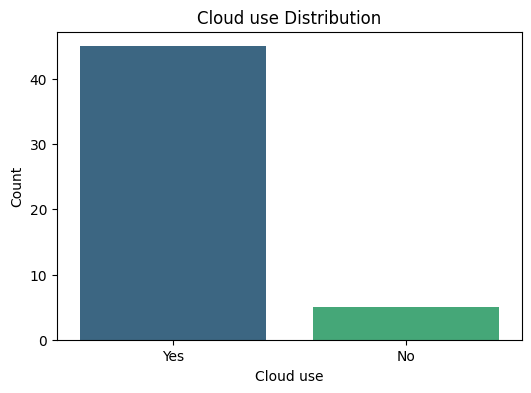

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='Cloud use',  palette='viridis',  data=df)

plt.title("Cloud use Distribution")
plt.xlabel("Cloud use")
plt.ylabel("Count")

plt.show()

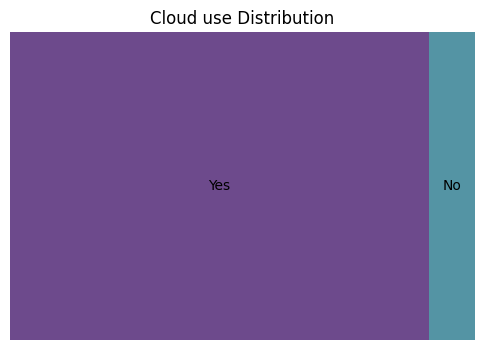

In [ ]:
!pip install squarify
import squarify
import matplotlib.pyplot as plt

freq = df['Cloud use'].value_counts()

plt.figure(figsize=(6,4))
squarify.plot(sizes=freq.values, label=freq.index, alpha=0.8)

plt.title("Cloud use Distribution")
plt.axis('off')

plt.show()

This bar chart shows that the vast majority of organizations in this survey are using cloud services.

"Yes" (Cloud User): Roughly 45 organizations.

"No" (Non-Cloud User): Only 5 organizations.

In short, cloud adoption is the standard for this group, outnumbering non-users by about 9 to 1.

In [11]:
yes_no_columns = [
    'Awareness of cybersecurity',
    'Cloud use',
    'Cyber security policy',
    'Awareness of National security framework',
    'Support to new cloud framework'
]

for col in yes_no_columns:
    print(f"\n{col}")
    print(df[col].value_counts())


Awareness of cybersecurity
Awareness of cybersecurity
Yes    48
No      2
Name: count, dtype: int64

Cloud use
Cloud use
Yes    45
No      5
Name: count, dtype: int64

Cyber security policy
Cyber security policy
Yes         46
Not sure     4
Name: count, dtype: int64

Awareness of National security framework
Awareness of National security framework
No          19
Yes         17
Not sure    14
Name: count, dtype: int64

Support to new cloud framework
Support to new cloud framework
Yes    43
No      7
Name: count, dtype: int64


In [ ]:
# Split multiple values and count them
Confidence= df['Confidence in detecting threats'].str.split(',').explode()
Confidence.value_counts()

,count
Confidence in detecting threats,
Very confident,27
Confident,21
Neutral,2


In [ ]:
def frequency_table(column):
    freq = df[column].value_counts()
    percent = df[column].value_counts(normalize=True) * 100
    table = pd.DataFrame({
        'Frequency': freq,
        'Percentage (%)': percent.round(2)
    })
    return table

frequency_table('Confidence in detecting threats')

,Frequency,Percentage (%)
Confidence in detecting threats,,
Very confident,27,54.0
Confident,21,42.0
Neutral,2,4.0


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.6/25.6 MB 27.5 MB/s eta 0:00:00


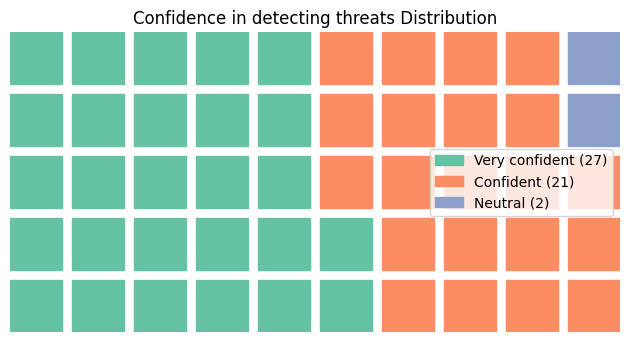

In [ ]:
!pip install pywaffle
from pywaffle import Waffle
import matplotlib.pyplot as plt

freq = df['Confidence in detecting threats'].value_counts()

fig = plt.figure(
    FigureClass=Waffle,
    rows=5,
    values=freq,
    labels=[f"{k} ({v})" for k,v in freq.items()],
    title={'label':'Confidence in detecting threats Distribution'}
)

plt.show()

This Waffle Chart shows how confident people feel about their ability to detect security threats. Each square represents one respondent.
<h3>The Breakdown:</h3>
<ul>
<li>Very Confident (27): More than half of the group feels highly capable of spotting threats.</li>
<li>Confident (21): A large portion feels generally secure, though perhaps less certain than the first group.</li>
<li>Neutral (2): Only a tiny fraction is unsure about their detection abilities.</li>
</ul>
The Big Picture: Overall sentiment is overwhelmingly positive. A total of 48 out of 50 people surveyed feel at least "Confident" in their threat detection.


In [ ]:
# Split multiple values and count them
Cloud_model= df['Cloud model'].str.split(',').explode()
Cloud_model.value_counts()

,count
Cloud model,
Private Cloud,25
Hybrid Cloud,14
Public Cloud,8
Not Sure,3


In [ ]:
def frequency_table(column):
    freq = df[column].value_counts()
    percent = df[column].value_counts(normalize=True) * 100
    table = pd.DataFrame({
        'Frequency': freq,
        'Percentage (%)': percent.round(2)
    })
    return table

frequency_table('Cloud model')

,Frequency,Percentage (%)
Cloud model,,
Private Cloud,25,50.0
Hybrid Cloud,14,28.0
Public Cloud,8,16.0
Not Sure,3,6.0


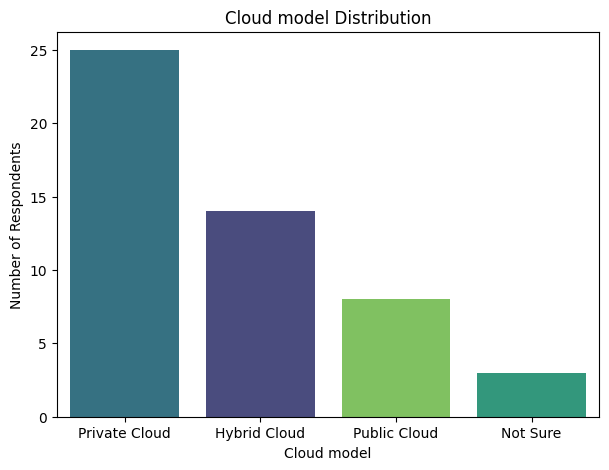

In [12]:
plt.figure(figsize=(7,5))
sns.countplot(
    x='Cloud model',
    data=df,
    order=df['Cloud model'].value_counts().index,
    palette='viridis',
    hue='Cloud model',
    legend=False
)

plt.title('Cloud model Distribution')
plt.xlabel('Cloud model')
plt.ylabel('Number of Respondents')
plt.show()


Private Cloud (25 respondents): The most popular choice. This means the cloud environment is dedicated solely to one organization, providing the most control and security.

Hybrid Cloud (14 respondents): The second most common. This is a "best of both worlds" approach, where an organization uses a mix of private and public clouds to share data and apps.

Public Cloud (8 respondents): Services like AWS or Google Cloud that are shared with other organizations over the public internet.

Not Sure (3 respondents): A small group that isn't certain which model they are using.

The takeaway: In this specific group, Private Cloud is the clear favorite, being used more than Hybrid and Public clouds combined.

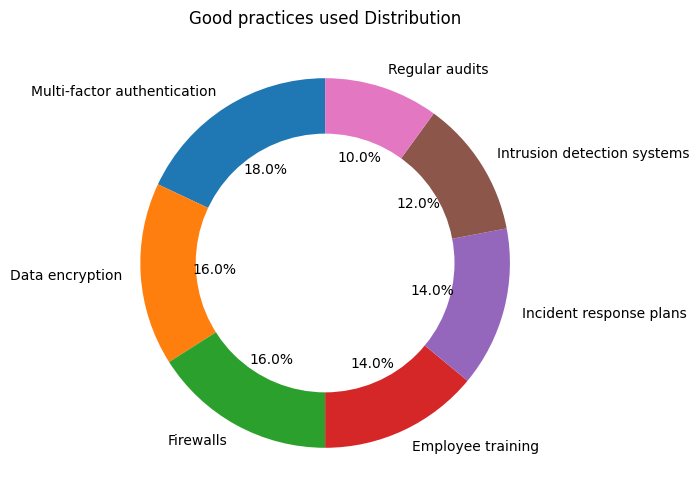

In [14]:
freq = df['Good practices'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(freq.values, labels=freq.index, autopct='%1.1f%%', startangle=90)

# Create donut hole
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Good practices used Distribution")
plt.show()


In [ ]:
# Split multiple values and count them
frameworks = df['Security frameworks'].str.split(',').explode()

frameworks.value_counts()

,count
Security frameworks,
27002,11
ISO/IEC 27001,11
NIST Cybersecurity Framework,8
800-53,7
NIST SP 800-210,7
COBIT,6
MITRE ATT&CK,4
CIS Controls Cloud Companion Guide,3
CSA Cloud Controls Matrix (CCM),3


In [ ]:
def frequency_table(column):
    freq = df[column].value_counts()
    percent = df[column].value_counts(normalize=True) * 100
    table = pd.DataFrame({
        'Frequency': freq,
        'Percentage (%)': percent.round(2)
    })
    return table

frequency_table('Security frameworks')

,Frequency,Percentage (%)
Security frameworks,,
"ISO/IEC 27001, 27002",10,20.0
NIST Cybersecurity Framework,8,16.0
"NIST SP 800-210, 800-53",7,14.0
COBIT,5,10.0
MITRE ATT&CK,4,8.0
CIS Controls Cloud Companion Guide,3,6.0
CIS Benchmarks for Cloud Platforms,3,6.0
ISO/IEC 27032,2,4.0
Azure Security Benchmark,2,4.0


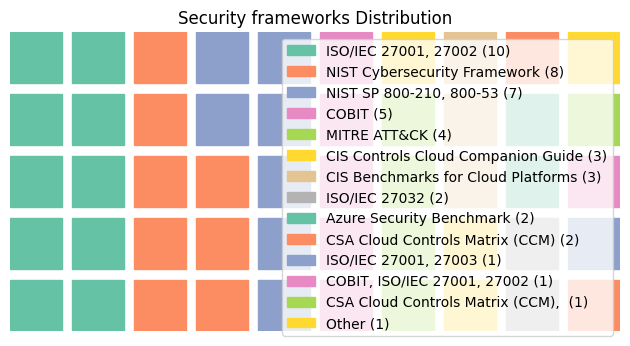

In [ ]:
!pip install pywaffle
from pywaffle import Waffle
import matplotlib.pyplot as plt

freq = df['Security frameworks'].value_counts()

fig = plt.figure(
    FigureClass=Waffle,
    rows=5,
    values=freq,
    labels=[f"{k} ({v})" for k,v in freq.items()],
    title={'label':'Security frameworks Distribution'}
)

plt.show()

This chart illustrates the distribution of various security frameworks used across a surveyed group. It uses a grid-based visualization where each square (or portion of a square) represents a count for a specific framework.
<p>Key Takeaways</p>

Most Popular: ISO/IEC 27001, 27002 is the most widely adopted framework in this set, represented by 10 units. <br>

Top Three: The top three spots are held by established international and national standards:
<ul>
<li>ISO/IEC 27001/27002 (10)</li>
<li>NIST Cybersecurity Framework (8)</li>
<li>NIST SP 800-210, 800-53 (7)</li>
</ul>
Cloud Focus: Several frameworks specifically targeting cloud security are present, such as the CIS Benchmarks for Cloud Platforms and the CSA Cloud Controls Matrix (CCM).

Complexity: The bottom of the list shows instances where organizations use a combination of frameworks (e.g., COBIT combined with ISO/IEC 27001) or "Other" unique frameworks.

In [ ]:
# Split multiple values and count them
Cloud_service_used = df['Cloud service used'].str.split(',').explode()

Cloud_service_used.value_counts()

,count
Cloud service used,
Infrastructure as a Service (IaaS),17
Software as a Service (SaaS),15
Platform as a Service (PaaS),14
Other,4


In [ ]:
def frequency_table(column):
    freq = df[column].value_counts()
    percent = df[column].value_counts(normalize=True) * 100
    table = pd.DataFrame({
        'Frequency': freq,
        'Percentage (%)': percent.round(2)
    })
    return table

frequency_table('Cloud service used')

,Frequency,Percentage (%)
Cloud service used,,
Infrastructure as a Service (IaaS),17,34.0
Software as a Service (SaaS),15,30.0
Platform as a Service (PaaS),14,28.0
Other,4,8.0


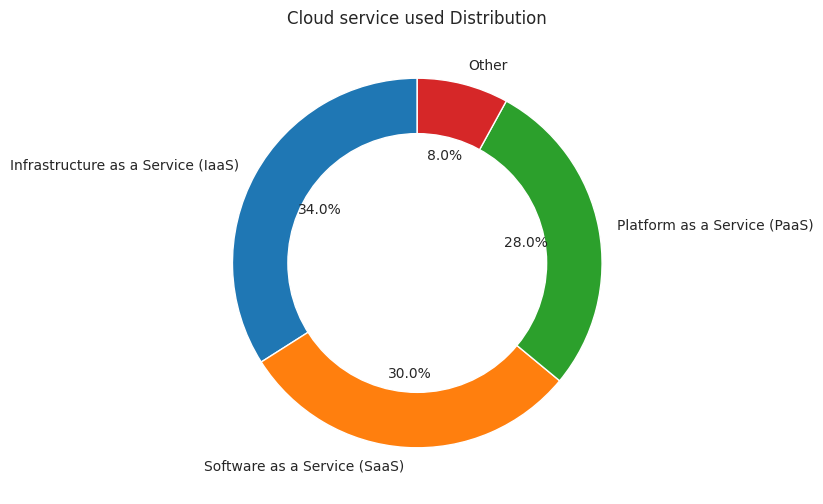

In [ ]:
freq = df['Cloud service used'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(freq.values, labels=freq.index, autopct='%1.1f%%', startangle=90)

# Create donut hole
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Cloud service used Distribution")
plt.show()

This donut chart shows the distribution of different types of cloud computing service models used within a specific group or market.
Core Service Models

The chart breaks down cloud usage into three primary categories, which represent different levels of control and management for the user:

1. Infrastructure as a Service (IaaS) - 34.0%: This is the largest segment. IaaS provides the fundamental building blocks—like virtual servers, storage, and networking. The user is responsible for managing the operating system, apps, and data (e.g., Amazon Web Services or Microsoft Azure).

2. Software as a Service (SaaS) - 30.0%: These are ready-to-use applications delivered over the internet. The provider manages everything, and the user just interacts with the software (e.g., Gmail, Slack, or Salesforce).

3. Platform as a Service (PaaS) - 28.0%: This provides a framework for developers to build, test, and deploy applications without worrying about the underlying infrastructure (e.g., Google App Engine or Heroku).

In [ ]:
# Split multiple values and count them
security_incident = df['Type of security incident'].str.split(',').explode()
security_incident.value_counts()


,count
Type of security incident,
Malware attacks,14
Service outages,12
Unauthorized access,10
Data breaches,7
Insider threats,4
Other,3


In [ ]:
def frequency_table(column):
    freq = df[column].value_counts()
    percent = df[column].value_counts(normalize=True) * 100
    table = pd.DataFrame({
        'Frequency': freq,
        'Percentage (%)': percent.round(2)
    })
    return table

frequency_table('Type of security incident')

,Frequency,Percentage (%)
Type of security incident,,
Malware attacks,14,28.0
Service outages,12,24.0
Unauthorized access,10,20.0
Data breaches,7,14.0
Insider threats,4,8.0
Other,3,6.0


/tmp/ipykernel_355/2843738001.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(x='Frequency', y='Type of security incident', data=df, palette='Blues_d')


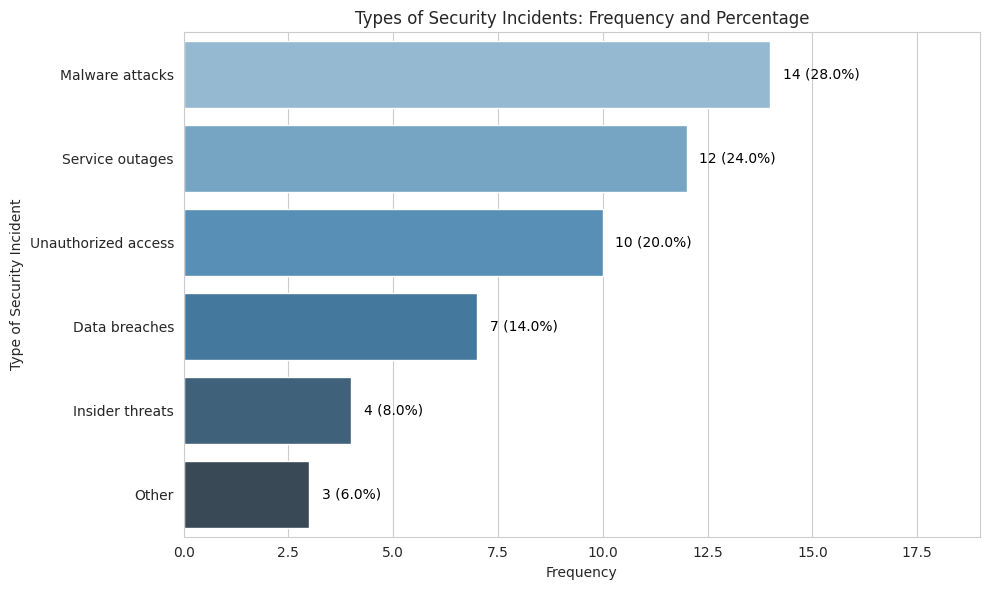

In [ ]:
data = {
    'Type of security incident': [
        'Malware attacks',
        'Service outages',
        'Unauthorized access',
        'Data breaches',
        'Insider threats',
        'Other'
    ],
    'Frequency': [14, 12, 10, 7, 4, 3],
    'Percentage (%)': [28.0, 24.0, 20.0, 14.0, 8.0, 6.0]
}

df = pd.DataFrame(data)

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
barplot = sns.barplot(x='Frequency', y='Type of security incident', data=df, palette='Blues_d')

# Annotate with frequency and percentage values
for index, row in df.iterrows():
    barplot.text(row['Frequency'] + 0.3, index, f"{row['Frequency']} ({row['Percentage (%)']}%)", color='black', va="center")

plt.title('Types of Security Incidents: Frequency and Percentage')
plt.xlabel('Frequency')
plt.ylabel('Type of Security Incident')
plt.xlim(0, max(df['Frequency']) + 5)
plt.tight_layout()
plt.show()

This horizontal bar chart illustrates the frequency and relative percentage of various security incident types based on a specific dataset.

Key Data Points

Malware attacks (28.0%) are the most frequent type of incident, occurring 14 times.

Service outages (24.0%) follow closely as the second most common issue (12 incidents), often as a byproduct of other attacks or infrastructure failures.

Unauthorized access (20.0%) and Data breaches (14.0%) represent nearly one-third of the total combined, highlighting significant risks to data confidentiality.

Insider threats (8.0%) are less frequent but often more damaging, involving individuals within the organization.

Broader Industry Context (2025–2026)

While this specific chart shows Malware at the top, broader industry reports from 2025 and 2026 highlight evolving shifts in these categories:

Dominant Attack Vectors: Reports for 2025 and 2026 indicate that Phishing has overtaken stolen credentials as the most common initial attack vector globally, accounting for roughly 16% of breaches.

Rising Complexity: Third-party and supply chain compromises have seen a dramatic increase, doubling to nearly 30% of all breaches in 2025.

Malware & Ransomware: Ransomware remains a critical subset of malware, appearing in approximately 44% of analyzed breaches in 2025, a significant rise from the previous year.

AI Influence: Attackers are increasingly using Generative AI for more sophisticated phishing and deepfake impersonation, with 16% of 2025 breaches involving AI-driven tactics.

Insider Dynamics: Although less frequent in some datasets, malicious insider attacks were reported as the costliest initial threat vector in 2025, averaging $4.92 million per incident.

In [ ]:
# Split multiple values and count them
Critical_cloud= df['Critical cloud threat'].str.split(',').explode()
Critical_cloud.value_counts()

,count
Critical cloud threat,
Data loss/leakage,20
Ransomware attacks,7
Data Breaches,7
Insecure APIs,6
Phishing and social engineering attacks,6
Unauthorized Access,3
Distributed Denial of Service (DDoS) attacks,1


In [ ]:
def frequency_table(column):
    freq = df[column].value_counts()
    percent = df[column].value_counts(normalize=True) * 100
    table = pd.DataFrame({
        'Frequency': freq,
        'Percentage (%)': percent.round(2)
    })
    return table

frequency_table('Critical cloud threat')

,Frequency,Percentage (%)
Critical cloud threat,,
Data loss/leakage,20,40.0
Ransomware attacks,7,14.0
Data Breaches,7,14.0
Insecure APIs,6,12.0
Phishing and social engineering attacks,6,12.0
Unauthorized Access,3,6.0
Distributed Denial of Service (DDoS) attacks,1,2.0


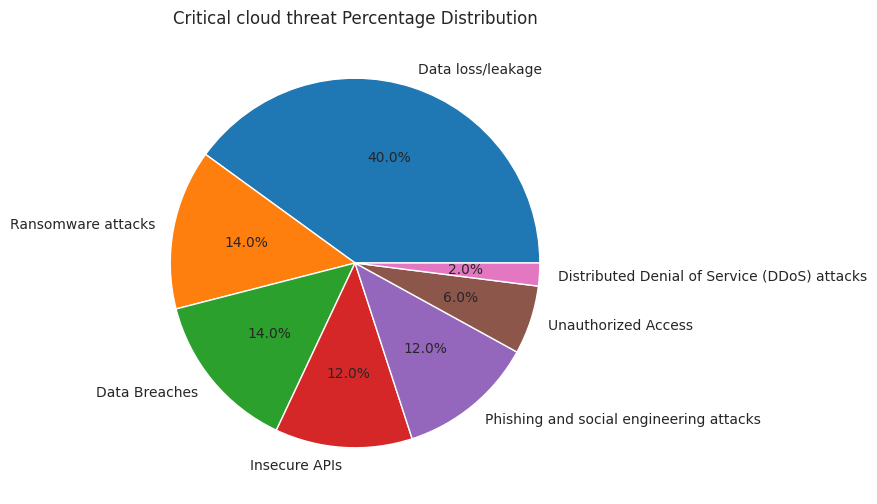

In [ ]:
df['Critical cloud threat'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)

plt.title('Critical cloud threat Percentage Distribution')
plt.ylabel('')

plt.show()

This pie chart illustrates the distribution of critical cloud security threats, identifying the most frequent types of attacks and vulnerabilities faced by organizations.
<h3>Dominant Threats</h3>
<ul>
<li>Data loss/leakage (40.0%): By far the largest concern, accounting for nearly half of all identified threats. This typically occurs through accidental exposure, such as incorrectly configured storage "buckets" left open to the public.</li>
<li>Ransomware & Data Breaches (28.0% combined): Both sit at 14.0% each. These are often linked; ransomware encrypts data to extort money, while breaches involve the unauthorized exfiltration of sensitive information.</li> </ul>

<h3>Emerging & Technical Risks</h3>
<ul>
<li>
Phishing and social engineering (12.0%): These attacks target human psychology rather than technical flaws. In 2026, these have become significantly harder to detect due to AI-driven voice cloning and hyper-personalized messaging.</li>
<li>Insecure APIs (12.0%): Because cloud services rely heavily on APIs to communicate, any "front door" without proper authentication is a major entry point for automated attacks.</li>
<li>Unauthorized Access (6.0%): This often stems from poor Identity and Access Management (IAM), such as giving excessive permissions to employees or failing to use multi-factor authentication (MFA).</li>
<li>DDoS attacks (2.0%): While less frequent in this specific dataset, these attacks aim to overwhelm cloud resources to cause service outages.

</li>
</ul>

In [ ]:
# Split multiple values and count them
cyber = df['Cyber security policy mention'].str.split(',').explode()
cyber.value_counts()

,count
Cyber security policy mention,
Data Protection Policy,21
Password Management Policy,13
Access Control Policy,11
Acceptable Use Policy,10
Password Management Policy,8
Information Security Policy,6
,6
Incident Response Policy,5
Not provided,4


In [ ]:
def frequency_table(column):
    freq = df[column].value_counts()
    percent = df[column].value_counts(normalize=True) * 100
    table = pd.DataFrame({
        'Frequency': freq,
        'Percentage (%)': percent.round(2)
    })
    return table

frequency_table('Cyber security policy mention')

,Frequency,Percentage (%)
Cyber security policy mention,,
Data Protection Policy,8,16.0
"Data Protection Policy, Password Management Policy",7,14.0
"Data Protection Policy, Acceptable Use Policy, Password Management Policy",6,12.0
"Password Management Policy, Access Control Policy,",6,12.0
Information Security Policy,6,12.0
"Access Control Policy, Incident Response Policy",5,10.0
Acceptable Use Policy,4,8.0
Not provided,4,8.0
Password Management Policy,2,4.0


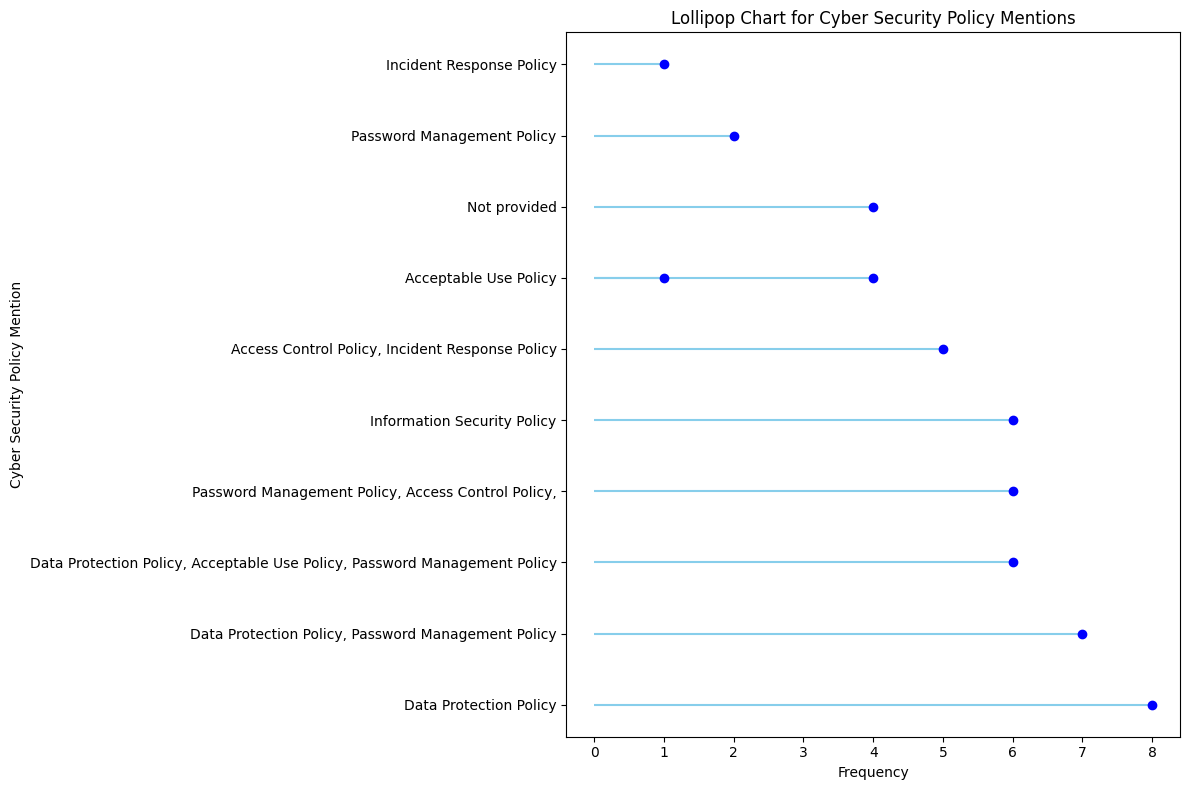

In [ ]:
plt.figure(figsize=(12,8))
plt.hlines(y=df['Cyber security policy mention'], xmin=0, xmax=df['Frequency'], color='skyblue')
plt.plot(df['Frequency'], df['Cyber security policy mention'], 'o', color='blue')
plt.xlabel('Frequency')
plt.ylabel('Cyber Security Policy Mention')
plt.title('Lollipop Chart for Cyber Security Policy Mentions')
plt.tight_layout()
plt.show()


This "lollipop chart" tracks the frequency of specific Cyber Security Policies (or combinations of policies) mentioned within a dataset.
The chart reveals a strong emphasis on Data Protection and Password Management, which are fundamental to modern compliance and risk mitigation.

Key Observations

Most Common Policy: Data Protection Policy stands alone at the top with a frequency of 8, making it the most frequently cited individual policy.
Frequent Combinations: Organizations often mention multiple policies together. For example:
Data Protection + Password Management appears 7 times.

The trio of Data Protection + Acceptable Use + Password Management appears 6 times.

Core Standards: The Information Security Policy—often the high-level umbrella for all other policies—ranks highly with 6 mentions.

Least Mentioned: Incident Response as a standalone mention is the least frequent (1), though it appears more often when bundled with Access Control.

Information Gap: A significant portion (4 mentions) are categorized as "Not provided," indicating a lack of formal documentation or disclosure in those instances.

Why these policies matter in 2026

In the current landscape, these policies are not just "best practices" but are often legally mandated:

Data Protection: Driven by evolving global regulations (like GDPR and its successors), this policy is critical for avoiding massive fines and maintaining consumer trust.

Access Control & Passwords: With the rise of AI-driven credential harvesting, these policies now strictly enforce Multi-Factor Authentication (MFA) and Zero Trust architectures.
Acceptable Use: Essential for governing how employees interact with Generative AI tools and remote work environments to prevent accidental data leaks.

In [ ]:
# Split multiple values and count them
Age = df['Age'].str.split(',').explode()
Age.value_counts()

,count
Age,
2534,38
3544,9
Under 25,3


In [ ]:
def frequency_table(column):
    freq = df[column].value_counts()
    percent = df[column].value_counts(normalize=True) * 100
    table = pd.DataFrame({
        'Frequency': freq,
        'Percentage (%)': percent.round(2)
    })
    return table

frequency_table('Age')

,Frequency,Percentage (%)
Age,,
2534,38,76.0
3544,9,18.0
Under 25,3,6.0


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 150 (\x96) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


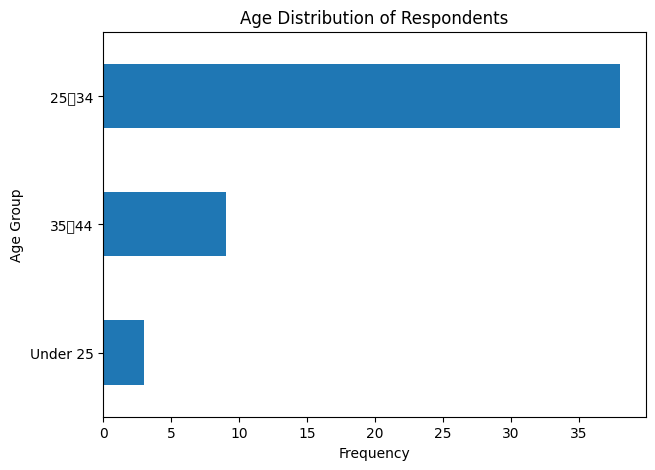

In [ ]:
freq = df['Age'].value_counts().sort_values()

plt.figure(figsize=(7,5))
freq.plot(kind='barh')

plt.title('Age Distribution of Respondents')
plt.xlabel('Frequency')
plt.ylabel('Age Group')

plt.show()

In [ ]:
# Split multiple values and count them
Age = df['Qualification'].str.split(',').explode()
Qualification.value_counts()

,count
Qualification,
Bachelors Degree,41
Masters Degree,9


In [ ]:
def frequency_table(column):
    freq = df[column].value_counts()
    percent = df[column].value_counts(normalize=True) * 100
    table = pd.DataFrame({
        'Frequency': freq,
        'Percentage (%)': percent.round(2)
    })
    return table

frequency_table('Qualification')

,Frequency,Percentage (%)
Qualification,,
Bachelors Degree,41,82.0
Masters Degree,9,18.0


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 146 (\x92) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


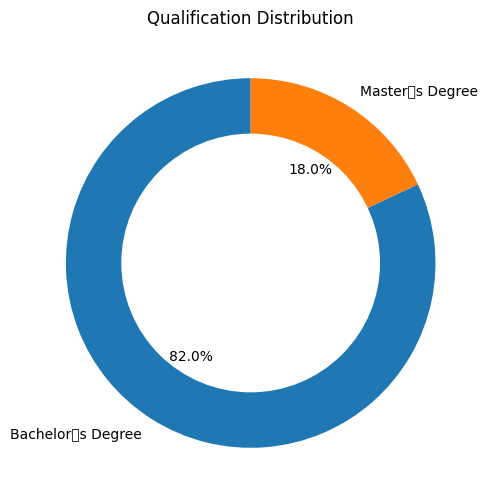

In [ ]:
freq = df['Qualification'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(freq.values, labels=freq.index, autopct='%1.1f%%', startangle=90)

# Create donut hole
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Qualification Distribution")
plt.show()

In [ ]:
# Split multiple values and count them
Department = df['Department'].str.split(',').explode()
Department.value_counts()

,count
Department,
E gov,18
Other,9
Network,8
Information security services,6
Cybersecurity,5
Information technology,4


In [ ]:
def frequency_table(column):
    freq = df[column].value_counts()
    percent = df[column].value_counts(normalize=True) * 100
    table = pd.DataFrame({
        'Frequency': freq,
        'Percentage (%)': percent.round(2)
    })
    return table

frequency_table('Department')

,Frequency,Percentage (%)
Department,,
E gov,18,36.0
Other,9,18.0
Network,8,16.0
Information security services,6,12.0
Cybersecurity,5,10.0
Information technology,4,8.0


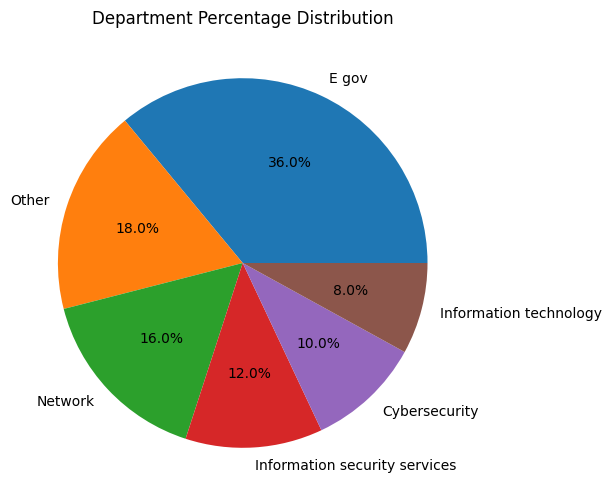

In [ ]:
df['Department'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)

plt.title('Department Percentage Distribution')
plt.ylabel('')

plt.show()

Available columns in the DataFrame:
Index(['Security frameworks', 'Number of Security Framework', 'Department',
       'Number of Departments ', 'Cloud service used',
       'Number Of Cloud service used', 'Cyber security policy ',
       'Number of Cyber security policy ', 'Type of security incident',
       'Number of security incident'],
      dtype='object')


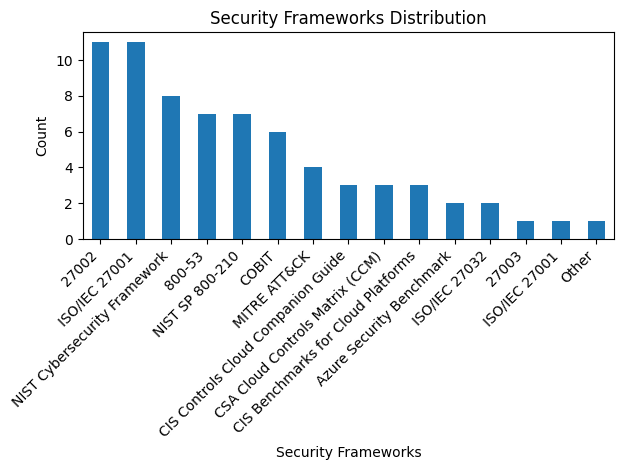

In [ ]:
print('Available columns in the DataFrame:')
print(df.columns)

ax = df.plot(kind='bar', x='Security frameworks', y='Number of Security Framework', legend=False,
             title='Security Frameworks Distribution')
ax.set_xlabel('Security Frameworks')
ax.set_ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
print('Available columns in the current DataFrame:')
print(df.columns)

# 'Number of Security Framework' is not in df after loading 'omara_data.csv'
# Using 'S/No' as an alternative numerical column from the current df
ax = df['S/No'].plot(kind='kde',
                     title='Distribution of S/No')
ax.set_xlabel('S/No')

In [ ]:
df = pd.read_csv("Omara_Final.csv", encoding='latin1')

In [ ]:
df.shape

(15, 10)

Text(0.5, 24.000000000000014, 'Number of Security Framework')

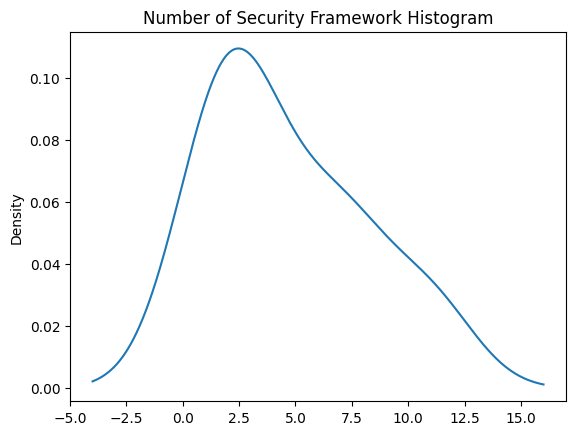

In [ ]:
df['Number of Security Framework'].plot(kind='kde',
                     title='Number of Security Framework Histogram'),
ax.set_xlabel('Number of Security Framework')

In [ ]:
df_corr = df[['Number of Security Framework',
    'Number of Departments ',
    'Number Of Cloud service used',
    'Number of Cyber security policy ']].dropna().corr()
df_corr

,Number of Security Framework,Number of Departments,Number Of Cloud service used,Number of Cyber security policy
Number of Security Framework,1.000000,0.722501,0.822065,0.753117
Number of Departments,0.722501,1.000000,0.697155,0.995689
Number Of Cloud service used,0.822065,0.697155,1.000000,0.673270
Number of Cyber security policy,0.753117,0.995689,0.673270,1.000000


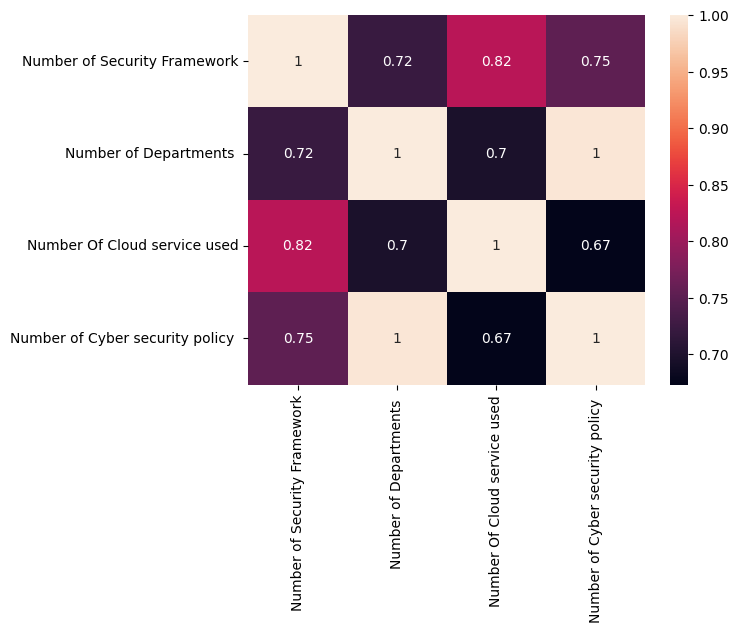

In [ ]:
sns.heatmap(df_corr, annot=True)
plt.show()

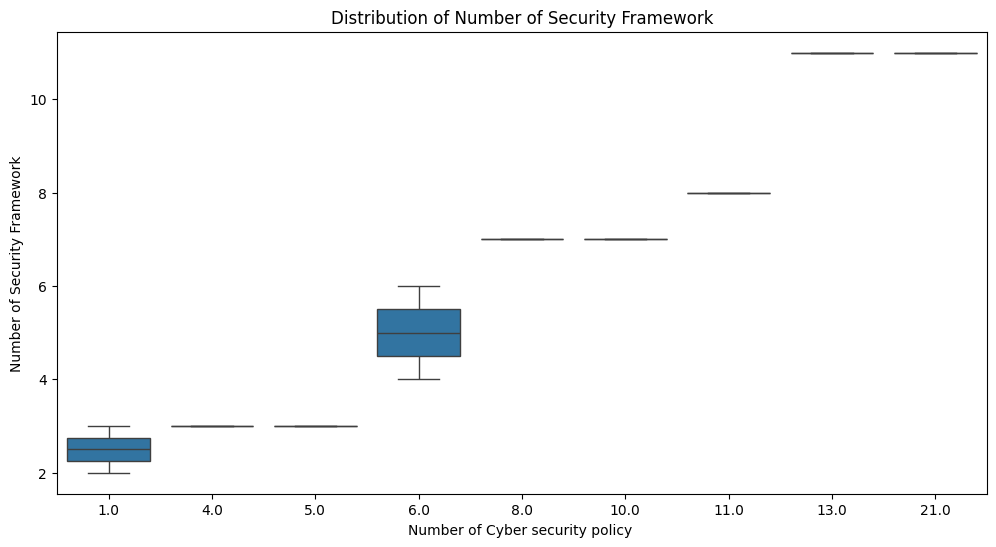

In [ ]:
plt.figure(figsize=(12,6))
sns.boxplot(y='Number of Security Framework', x='Number of Cyber security policy ', data=df) # Corrected column name to include trailing space
plt.title('Distribution of Number of Security Framework')
plt.show()